# Rotate And Crop Video Batch

Batch-process concatenated behavior camera videos with per-video rotation and crop settings.

Workflow:
1. Build a per-video config table.
2. Preview rotation only for each video.
3. Edit any per-video angles or crop boxes.
4. Preview rotation plus crop for each video.
5. Run the full batch export.

In [1]:
from pathlib import Path
import math
import ffmpeg
import pandas as pd
from IPython.display import Image, Markdown, display
from tqdm import tqdm


def probe_video(video_path):
    probe = ffmpeg.probe(str(video_path))
    video_stream = next(stream for stream in probe['streams'] if stream['codec_type'] == 'video')
    width = int(video_stream['width'])
    height = int(video_stream['height'])
    duration = float(video_stream['duration'])
    codec_name = video_stream.get('codec_name', 'Unknown')
    return {
        'width': width,
        'height': height,
        'duration_sec': duration,
        'codec_name': codec_name,
    }


def compute_rotated_canvas(width, height, angle_degrees):
    angle_rad = math.radians(angle_degrees)
    new_width = int(abs(width * math.cos(angle_rad)) + abs(height * math.sin(angle_rad)))
    new_height = int(abs(width * math.sin(angle_rad)) + abs(height * math.cos(angle_rad)))
    return angle_rad, new_width, new_height


def normalize_crop_box(crop_box=None, vertices=None):
    if crop_box is None and vertices is None:
        raise ValueError('Provide either crop_box or vertices.')

    if crop_box is not None:
        return {
            'crop_x': int(crop_box['crop_x']),
            'crop_y': int(crop_box['crop_y']),
            'crop_width': int(crop_box['crop_width']),
            'crop_height': int(crop_box['crop_height']),
        }

    x_coordinates = [v[0] for v in vertices]
    y_coordinates = [v[1] for v in vertices]
    x_min = min(x_coordinates)
    x_max = max(x_coordinates)
    y_min = min(y_coordinates)
    y_max = max(y_coordinates)
    return {
        'crop_x': int(x_min),
        'crop_y': int(y_min),
        'crop_width': int(x_max - x_min),
        'crop_height': int(y_max - y_min),
    }


def clamp_crop_box(crop_box, frame_width, frame_height):
    crop_x = max(0, int(crop_box['crop_x']))
    crop_y = max(0, int(crop_box['crop_y']))
    crop_width = int(crop_box['crop_width'])
    crop_height = int(crop_box['crop_height'])

    if crop_width <= 0 or crop_height <= 0:
        raise ValueError(f'Invalid crop size: {crop_width} x {crop_height}')

    if crop_x + crop_width > frame_width or crop_y + crop_height > frame_height:
        raise ValueError(
            f"Crop box {(crop_x, crop_y, crop_width, crop_height)} exceeds frame bounds {(frame_width, frame_height)}"
        )

    return {
        'crop_x': crop_x,
        'crop_y': crop_y,
        'crop_width': crop_width,
        'crop_height': crop_height,
    }


def build_output_path(input_path, output_dir, suffix):
    return output_dir / f'{input_path.stem}{suffix}.avi'


def build_rotated_output_path(input_path, output_dir):
    return build_output_path(input_path, output_dir, suffix='_rotated')


def build_cropped_output_path(input_path, output_dir):
    return build_output_path(input_path, output_dir, suffix='_rotated_cropped')


def build_video_config_df(input_dir, default_angle_degrees, default_crop_box, pattern='*.mp4'):
    input_dir = Path(input_dir)
    video_files = sorted(input_dir.glob(pattern))
    if not video_files:
        raise FileNotFoundError(f'No files matching {pattern!r} found in {input_dir}')

    rows = []
    for video_path in video_files:
        rows.append({
            'file_name': video_path.name,
            'input_file': str(video_path),
            'angle_degrees': float(default_angle_degrees),
            'crop_x': int(default_crop_box['crop_x']),
            'crop_y': int(default_crop_box['crop_y']),
            'crop_width': int(default_crop_box['crop_width']),
            'crop_height': int(default_crop_box['crop_height']),
            'enabled': True,
        })

    return pd.DataFrame(rows)


def build_rotated_stream(input_path, angle_degrees, preview_time_sec=None):
    info = probe_video(input_path)
    angle_rad, rotated_width, rotated_height = compute_rotated_canvas(
        info['width'], info['height'], angle_degrees
    )

    input_kwargs = {}
    if preview_time_sec is not None:
        input_kwargs['ss'] = max(0, float(preview_time_sec))

    stream = (
        ffmpeg
        .input(str(input_path), **input_kwargs)
        .filter(
            'pad',
            rotated_width,
            rotated_height,
            (rotated_width - info['width']) // 2,
            (rotated_height - info['height']) // 2,
            color='0xFFFFFF'
        )
        .filter('rotate', str(angle_rad))
    )

    transform_info = {
        'duration_sec': info['duration_sec'],
        'input_codec': info['codec_name'],
        'rotated_width': rotated_width,
        'rotated_height': rotated_height,
    }
    return stream, transform_info


def build_rotated_cropped_stream(input_path, angle_degrees, crop_box, preview_time_sec=None):
    stream, info = build_rotated_stream(
        input_path=input_path,
        angle_degrees=angle_degrees,
        preview_time_sec=preview_time_sec,
    )
    crop_box = clamp_crop_box(crop_box, info['rotated_width'], info['rotated_height'])
    stream = stream.filter(
        'crop',
        crop_box['crop_width'],
        crop_box['crop_height'],
        crop_box['crop_x'],
        crop_box['crop_y'],
    )
    info.update(crop_box)
    return stream, info


def render_frame_from_stream(stream, input_name):
    out, err = (
        stream
        .output('pipe:', vframes=1, format='image2', vcodec='png')
        .global_args('-loglevel', 'error')
        .run(capture_stdout=True, capture_stderr=True)
    )
    if not out:
        error_text = err.decode('utf-8', errors='replace').strip()
        raise RuntimeError(error_text or f'Could not render preview frame for {input_name}')
    return out


def preview_rotation_only(config_df, preview_time_fraction=0.5):
    results = []
    enabled_df = config_df.loc[config_df['enabled']].reset_index(drop=True)
    for row in tqdm(enabled_df.itertuples(index=False), total=len(enabled_df), desc='Rotation previews', unit='file'):
        input_path = Path(row.input_file)
        info = probe_video(input_path)
        preview_time_sec = info['duration_sec'] * preview_time_fraction
        stream, transform_info = build_rotated_stream(
            input_path=input_path,
            angle_degrees=row.angle_degrees,
            preview_time_sec=preview_time_sec,
        )
        image_bytes = render_frame_from_stream(stream, input_path.name)

        display(Markdown(
            f"### Rotation preview: {input_path.name}\n"
            f"Angle: `{row.angle_degrees}`  \n"
            f"Preview time: `{preview_time_sec:.2f}s`  \n"
            f"Rotated canvas: `{transform_info['rotated_width']} x {transform_info['rotated_height']}`"
        ))
        display(Image(data=image_bytes))

        results.append({
            'file_name': row.file_name,
            'preview_time_sec': preview_time_sec,
            'angle_degrees': row.angle_degrees,
            'rotated_width': transform_info['rotated_width'],
            'rotated_height': transform_info['rotated_height'],
        })

    return pd.DataFrame(results)


def preview_rotated_and_cropped(config_df, preview_time_fraction=0.5):
    results = []
    enabled_df = config_df.loc[config_df['enabled']].reset_index(drop=True)
    for row in tqdm(enabled_df.itertuples(index=False), total=len(enabled_df), desc='Crop previews', unit='file'):
        input_path = Path(row.input_file)
        info = probe_video(input_path)
        preview_time_sec = info['duration_sec'] * preview_time_fraction
        stream, transform_info = build_rotated_cropped_stream(
            input_path=input_path,
            angle_degrees=row.angle_degrees,
            crop_box={
                'crop_x': row.crop_x,
                'crop_y': row.crop_y,
                'crop_width': row.crop_width,
                'crop_height': row.crop_height,
            },
            preview_time_sec=preview_time_sec,
        )
        image_bytes = render_frame_from_stream(stream, input_path.name)

        display(Markdown(
            f"### Rotation + crop preview: {input_path.name}\n"
            f"Angle: `{row.angle_degrees}`  \n"
            f"Preview time: `{preview_time_sec:.2f}s`  \n"
            f"Crop box: `x={transform_info['crop_x']}, y={transform_info['crop_y']}, w={transform_info['crop_width']}, h={transform_info['crop_height']}`"
        ))
        display(Image(data=image_bytes))

        results.append({
            'file_name': row.file_name,
            'preview_time_sec': preview_time_sec,
            'angle_degrees': row.angle_degrees,
            'crop_x': transform_info['crop_x'],
            'crop_y': transform_info['crop_y'],
            'crop_width': transform_info['crop_width'],
            'crop_height': transform_info['crop_height'],
        })

    return pd.DataFrame(results)


def rotate_video_only(input_path, output_path, angle_degrees, overwrite=False):
    stream, info = build_rotated_stream(
        input_path=input_path,
        angle_degrees=angle_degrees,
    )

    ffmpeg_command = (
        stream
        .output(str(output_path), vcodec='mjpeg', qscale=3)
        .global_args('-progress', 'pipe:1', '-nostats', '-loglevel', 'error')
    )

    process = ffmpeg_command.run_async(
        pipe_stdout=True,
        pipe_stderr=True,
        overwrite_output=overwrite,
    )

    pbar = tqdm(
        total=info['duration_sec'],
        desc=input_path.name,
        unit='s',
        dynamic_ncols=True,
        leave=False,
    )

    for raw_line in process.stdout:
        line = raw_line.decode('utf-8', errors='replace').strip()
        if line.startswith('out_time_ms='):
            out_time_ms = int(line.split('=', 1)[1])
            current_time = out_time_ms / 1_000_000
            pbar.update(max(0, current_time - pbar.n))
        elif line == 'progress=end':
            break

    pbar.close()
    return_code = process.wait()
    stderr_output = process.stderr.read().decode('utf-8', errors='replace').strip()

    if return_code != 0:
        raise RuntimeError(stderr_output or f'ffmpeg failed with exit code {return_code}')

    return {
        'input_file': str(input_path),
        'output_file': str(output_path),
        'duration_sec': info['duration_sec'],
        'input_codec': info['input_codec'],
        'rotated_width': info['rotated_width'],
        'rotated_height': info['rotated_height'],
        'angle_degrees': angle_degrees,
    }


def crop_rotated_video(input_path, output_path, crop_box, overwrite=False):
    info = probe_video(input_path)
    crop_box = clamp_crop_box(crop_box, info['width'], info['height'])

    ffmpeg_command = (
        ffmpeg
        .input(str(input_path))
        .filter(
            'crop',
            crop_box['crop_width'],
            crop_box['crop_height'],
            crop_box['crop_x'],
            crop_box['crop_y'],
        )
        .output(str(output_path), vcodec='mjpeg', qscale=3)
        .global_args('-progress', 'pipe:1', '-nostats', '-loglevel', 'error')
    )

    process = ffmpeg_command.run_async(
        pipe_stdout=True,
        pipe_stderr=True,
        overwrite_output=overwrite,
    )

    pbar = tqdm(
        total=info['duration_sec'],
        desc=input_path.name,
        unit='s',
        dynamic_ncols=True,
        leave=False,
    )

    for raw_line in process.stdout:
        line = raw_line.decode('utf-8', errors='replace').strip()
        if line.startswith('out_time_ms='):
            out_time_ms = int(line.split('=', 1)[1])
            current_time = out_time_ms / 1_000_000
            pbar.update(max(0, current_time - pbar.n))
        elif line == 'progress=end':
            break

    pbar.close()
    return_code = process.wait()
    stderr_output = process.stderr.read().decode('utf-8', errors='replace').strip()

    if return_code != 0:
        raise RuntimeError(stderr_output or f'ffmpeg failed with exit code {return_code}')

    return {
        'input_file': str(input_path),
        'output_file': str(output_path),
        'duration_sec': info['duration_sec'],
        'input_codec': info['codec_name'],
        'crop_x': crop_box['crop_x'],
        'crop_y': crop_box['crop_y'],
        'crop_width': crop_box['crop_width'],
        'crop_height': crop_box['crop_height'],
    }


def batch_rotate_from_config(config_df, rotated_output_dir, overwrite=False):
    rotated_output_dir = Path(rotated_output_dir)
    rotated_output_dir.mkdir(parents=True, exist_ok=True)

    enabled_df = config_df.loc[config_df['enabled']].reset_index(drop=True)
    if enabled_df.empty:
        raise ValueError('No enabled videos found in config_df')

    results = []
    for row in tqdm(enabled_df.itertuples(index=False), total=len(enabled_df), desc='Rotate files', unit='file'):
        input_path = Path(row.input_file)
        output_path = build_rotated_output_path(input_path, rotated_output_dir)

        if output_path.exists() and not overwrite:
            results.append({
                'input_file': str(input_path),
                'output_file': str(output_path),
                'status': 'skipped_existing',
            })
            continue

        try:
            result = rotate_video_only(
                input_path=input_path,
                output_path=output_path,
                angle_degrees=row.angle_degrees,
                overwrite=overwrite,
            )
            result['status'] = 'processed'
            results.append(result)
        except Exception as exc:
            results.append({
                'input_file': str(input_path),
                'output_file': str(output_path),
                'status': 'error',
                'error': str(exc),
            })

    return pd.DataFrame(results)


def batch_crop_from_config(config_df, rotated_output_dir, cropped_output_dir, overwrite=False):
    rotated_output_dir = Path(rotated_output_dir)
    cropped_output_dir = Path(cropped_output_dir)
    cropped_output_dir.mkdir(parents=True, exist_ok=True)

    enabled_df = config_df.loc[config_df['enabled']].reset_index(drop=True)
    if enabled_df.empty:
        raise ValueError('No enabled videos found in config_df')

    results = []
    for row in tqdm(enabled_df.itertuples(index=False), total=len(enabled_df), desc='Crop files', unit='file'):
        original_input_path = Path(row.input_file)
        rotated_input_path = build_rotated_output_path(original_input_path, rotated_output_dir)
        output_path = build_cropped_output_path(original_input_path, cropped_output_dir)

        if not rotated_input_path.exists():
            results.append({
                'input_file': str(original_input_path),
                'rotated_input_file': str(rotated_input_path),
                'output_file': str(output_path),
                'status': 'missing_rotated_input',
            })
            continue

        if output_path.exists() and not overwrite:
            results.append({
                'input_file': str(original_input_path),
                'rotated_input_file': str(rotated_input_path),
                'output_file': str(output_path),
                'status': 'skipped_existing',
            })
            continue

        try:
            result = crop_rotated_video(
                input_path=rotated_input_path,
                output_path=output_path,
                crop_box={
                    'crop_x': row.crop_x,
                    'crop_y': row.crop_y,
                    'crop_width': row.crop_width,
                    'crop_height': row.crop_height,
                },
                overwrite=overwrite,
            )
            result['source_input_file'] = str(original_input_path)
            result['rotated_input_file'] = str(rotated_input_path)
            result['status'] = 'processed'
            results.append(result)
        except Exception as exc:
            results.append({
                'input_file': str(original_input_path),
                'rotated_input_file': str(rotated_input_path),
                'output_file': str(output_path),
                'status': 'error',
                'error': str(exc),
            })

    return pd.DataFrame(results)


In [12]:
input_dir = Path("/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackEzTrack/BehavCamConcactenated_311")
rotated_output_dir = input_dir / 'rotated_avi'
cropped_output_dir = input_dir / 'rotated_and_cropped_avi'

Bx = 49
By = 372
Width = 661
Height = 35

default_angle_to_rotate = 30
default_crop_box = normalize_crop_box(vertices=[(Bx, By), (Bx+Width, By), (Bx+Width, By+Height), (Bx, By+Height)])
preview_time_fraction = 0.5
overwrite_existing = False

video_config_df = build_video_config_df(
    input_dir=input_dir,
    default_angle_degrees=default_angle_to_rotate,
    default_crop_box=default_crop_box,
    pattern='*.mp4',
)

print(f'Found {len(video_config_df)} input videos in {input_dir}')
print(f'Rotated output directory: {rotated_output_dir}')
print(f'Cropped output directory: {cropped_output_dir}')
video_config_df

Found 17 input videos in /Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackEzTrack/BehavCamConcactenated_311
Rotated output directory: /Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackEzTrack/BehavCamConcactenated_311/rotated_avi
Cropped output directory: /Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackEzTrack/BehavCamConcactenated_311/rotated_and_cropped_avi


,file_name,input_file,angle_degrees,crop_x,crop_y,crop_width,crop_height,enabled
0,m311_02042025_19_15_29_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,49,372,661,35,True
1,m311_03042025_15_39_01_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,49,372,661,35,True
2,m311_04022025_19_15_29_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,49,372,661,35,True
3,m311_04032025_15_39_01_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,49,372,661,35,True
4,m311_04042025_21_05_03_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,49,372,661,35,True
5,m311_04082025_16_21_42_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,49,372,661,35,True
6,m311_04092025_15_28_20_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,49,372,661,35,True
7,m311_04102025_16_39_41_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,49,372,661,35,True
8,m311_05042025_18_35_11_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,49,372,661,35,True
9,m311_05042025_19_12_36_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,49,372,661,35,True


In [6]:
# Edit per-video settings here before running previews or batch export.

#default_crop_box = normalize_crop_box(vertices=[(Bx, By), (Bx+Width, By), (Bx+Width, By+Height), (Bx, By+Height)])
# Examples:
#video_config_df.loc[video_config_df['file_name'] == 'm992_12302024_19_59_56_concactenatedbehavCam00_behavCam15.mp4', 'angle_degrees'] = 28
#video_config_df.loc[video_config_df['file_name'] == 'm752_01102024_16_18_25_concactenatedbehavCam00_behavCam17.mp4', ['crop_x', 'crop_y', 'crop_width', 'crop_height']] = [85, 351, 661, 45]

# video_config_df.loc[video_config_df['file_name'] == 'some_file.mp4', 'enabled'] = False

video_config_df

,file_name,input_file,angle_degrees,crop_x,crop_y,crop_width,crop_height,enabled
0,m311_02042025_19_15_29_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,78,360,658,41,True
1,m311_03042025_15_39_01_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,78,360,658,41,True
2,m311_04022025_19_15_29_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,78,360,658,41,True
3,m311_04032025_15_39_01_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,78,360,658,41,True
4,m311_04042025_21_05_03_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,78,360,658,41,True
5,m311_04082025_16_21_42_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,78,360,658,41,True
6,m311_04092025_15_28_20_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,78,360,658,41,True
7,m311_04102025_16_39_41_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,78,360,658,41,True
8,m311_05042025_18_35_11_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,78,360,658,41,True
9,m311_05042025_19_12_36_concactenatedbehavCam00...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,30.0,78,360,658,41,True


Rotation previews:   0%|                               | 0/17 [00:00<?, ?file/s]

### Rotation preview: m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.47s`  
Rotated canvas: `794 x 735`

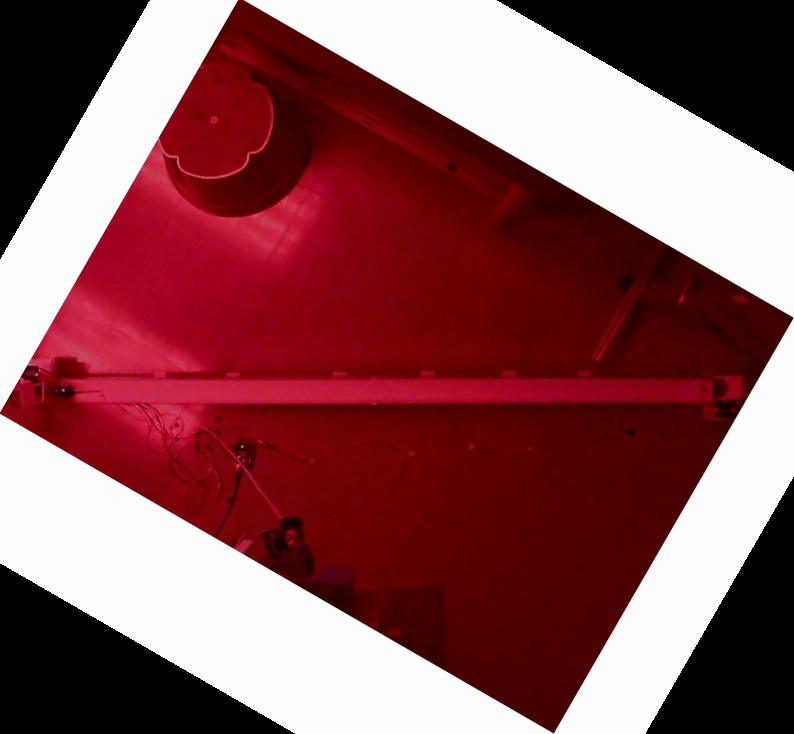

Rotation previews:   6%|█▎                     | 1/17 [00:00<00:14,  1.12file/s]

### Rotation preview: m311_03042025_15_39_01_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.43s`  
Rotated canvas: `794 x 735`

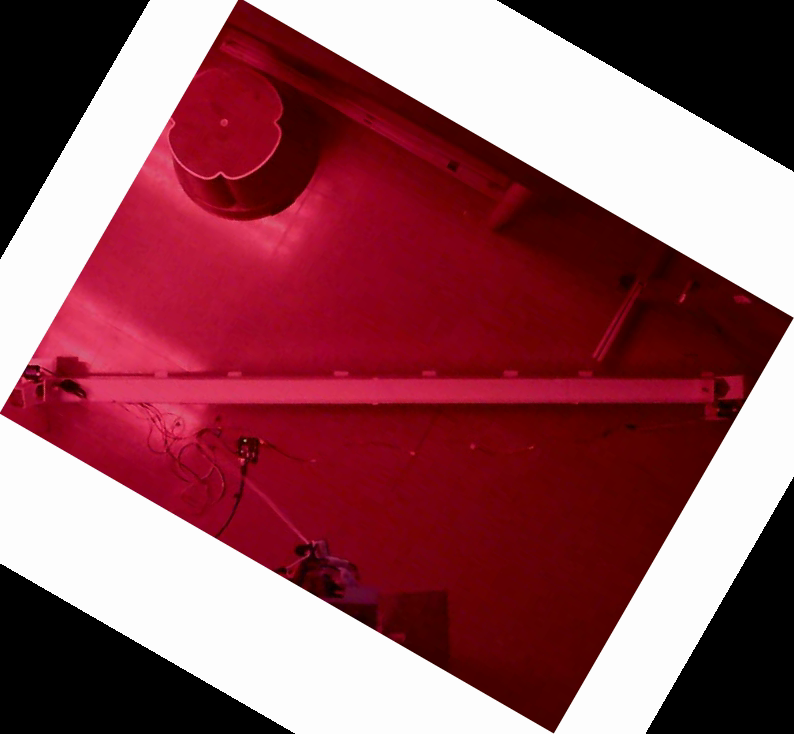

Rotation previews:  12%|██▋                    | 2/17 [00:01<00:09,  1.51file/s]

### Rotation preview: m311_04022025_19_15_29_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.47s`  
Rotated canvas: `794 x 735`

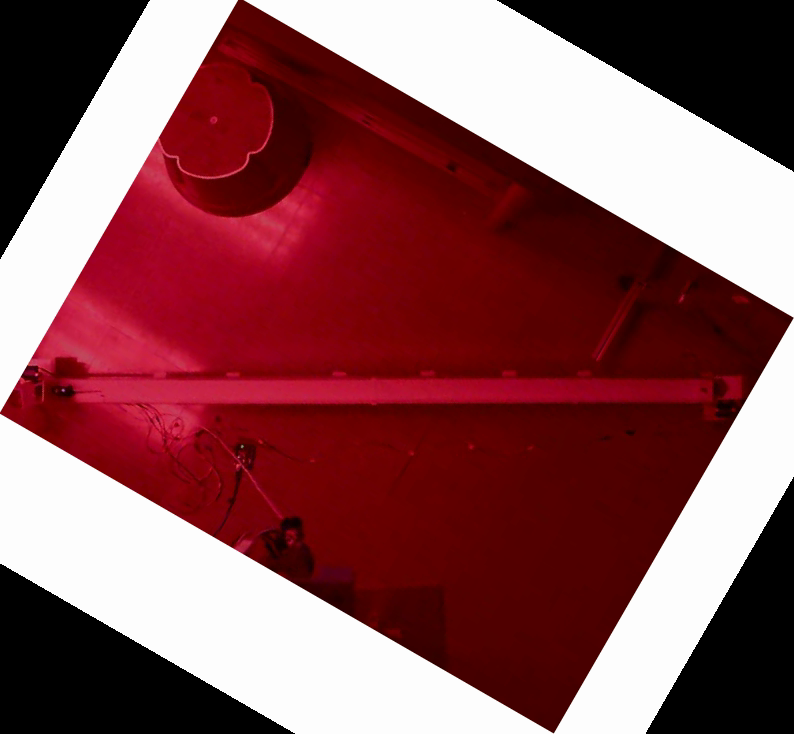

Rotation previews:  18%|████                   | 3/17 [00:01<00:08,  1.70file/s]

### Rotation preview: m311_04032025_15_39_01_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.43s`  
Rotated canvas: `794 x 735`

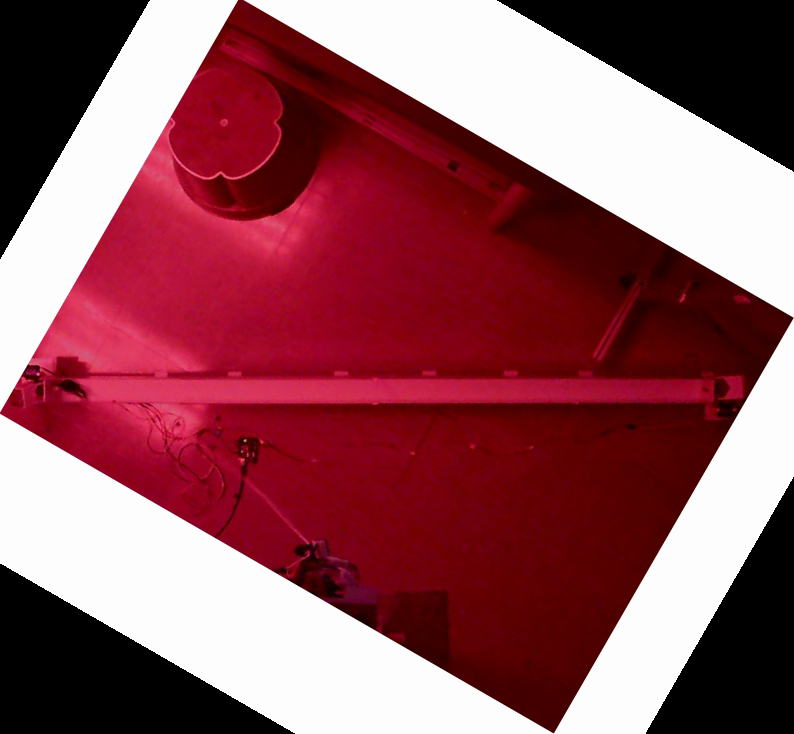

Rotation previews:  24%|█████▍                 | 4/17 [00:02<00:07,  1.81file/s]

### Rotation preview: m311_04042025_21_05_03_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.42s`  
Rotated canvas: `794 x 735`

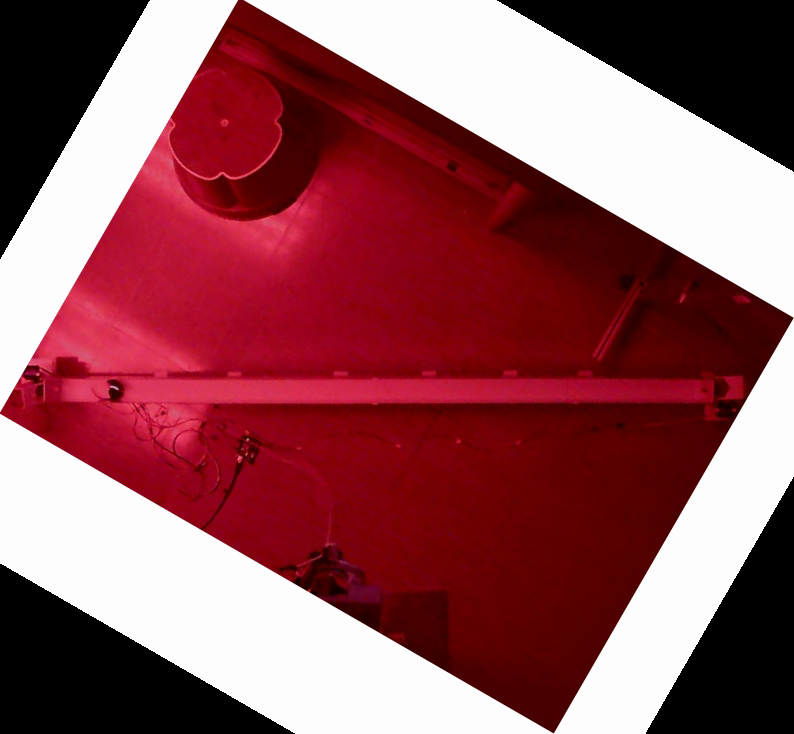

Rotation previews:  29%|██████▊                | 5/17 [00:02<00:06,  1.87file/s]

### Rotation preview: m311_04082025_16_21_42_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.33s`  
Rotated canvas: `794 x 735`

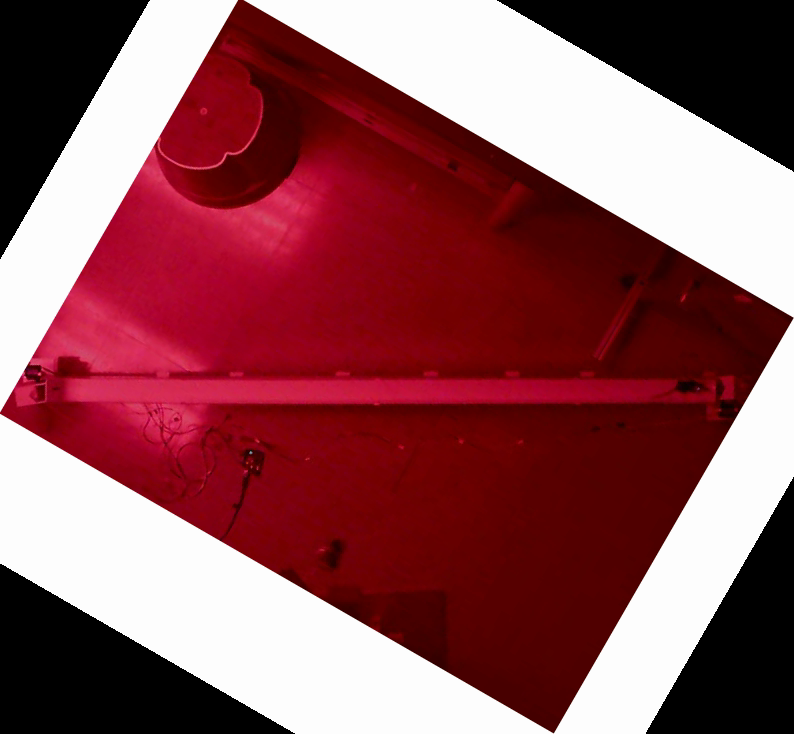

Rotation previews:  35%|████████               | 6/17 [00:03<00:05,  1.91file/s]

### Rotation preview: m311_04092025_15_28_20_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.42s`  
Rotated canvas: `794 x 735`

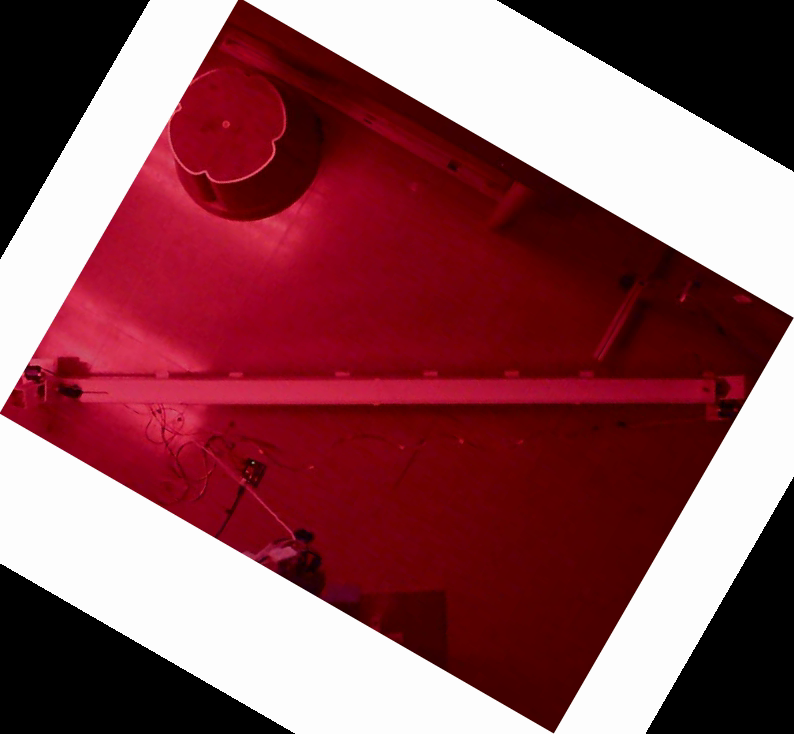

Rotation previews:  41%|█████████▍             | 7/17 [00:03<00:05,  1.94file/s]

### Rotation preview: m311_04102025_16_39_41_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.41s`  
Rotated canvas: `794 x 735`

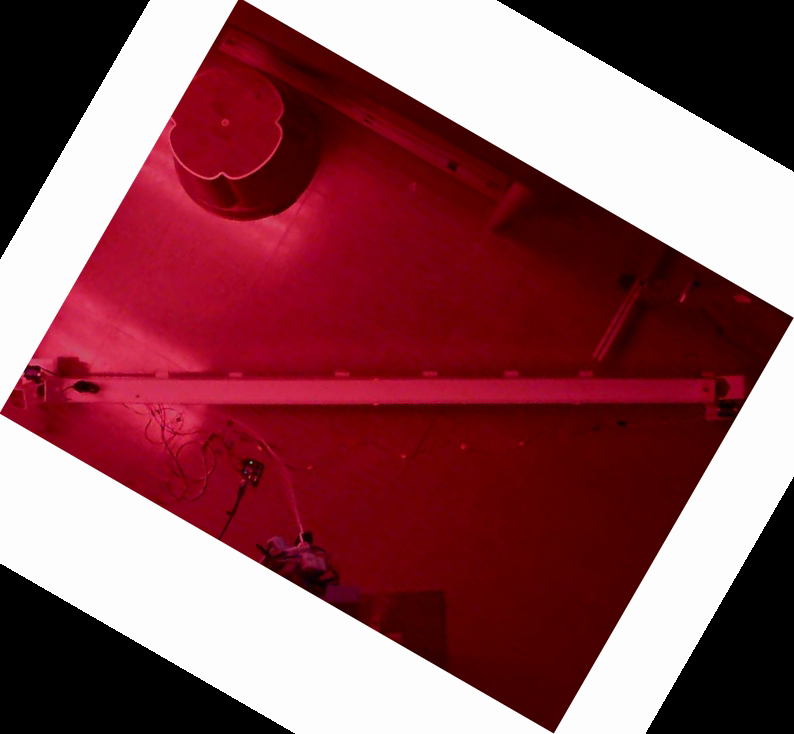

Rotation previews:  47%|██████████▊            | 8/17 [00:04<00:04,  1.98file/s]

### Rotation preview: m311_05042025_18_35_11_concactenatedbehavCam00_behavCam13.mp4
Angle: `30.0`  
Preview time: `113.53s`  
Rotated canvas: `794 x 735`

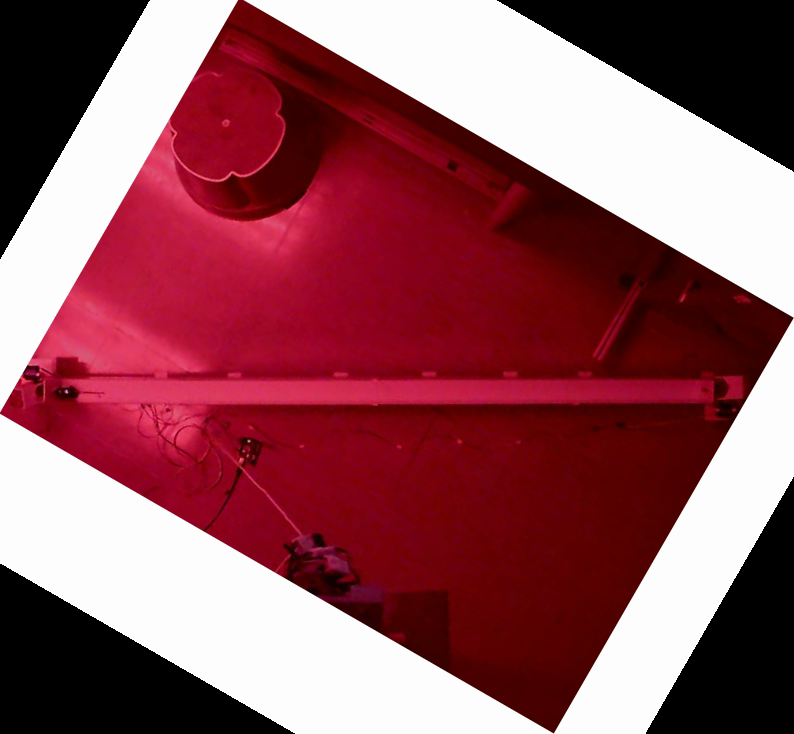

Rotation previews:  53%|████████████▏          | 9/17 [00:04<00:04,  1.97file/s]

### Rotation preview: m311_05042025_19_12_36_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.41s`  
Rotated canvas: `794 x 735`

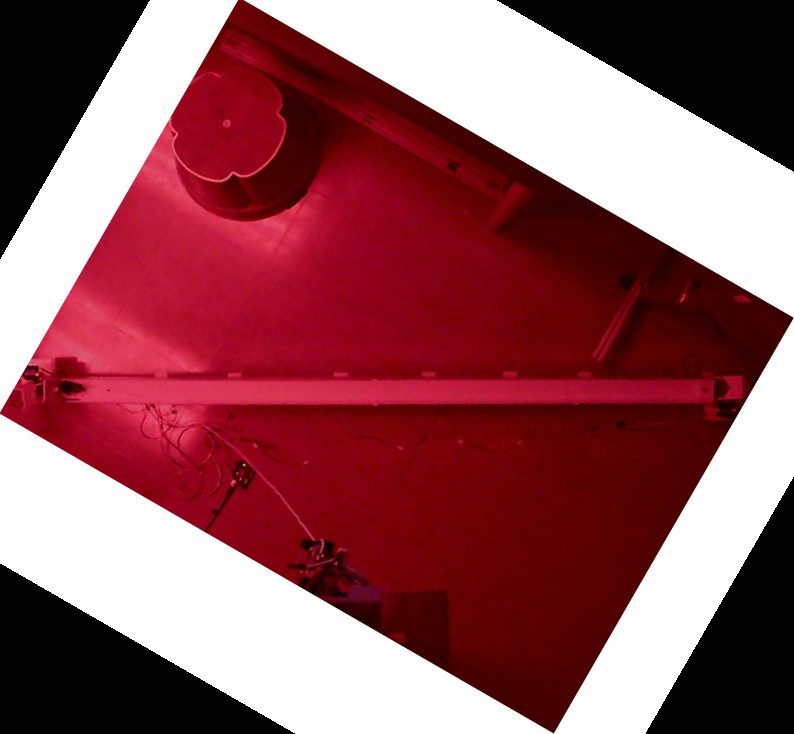

Rotation previews:  59%|████████████▉         | 10/17 [00:05<00:03,  1.97file/s]

### Rotation preview: m311_06042025_18_46_48_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.41s`  
Rotated canvas: `794 x 735`

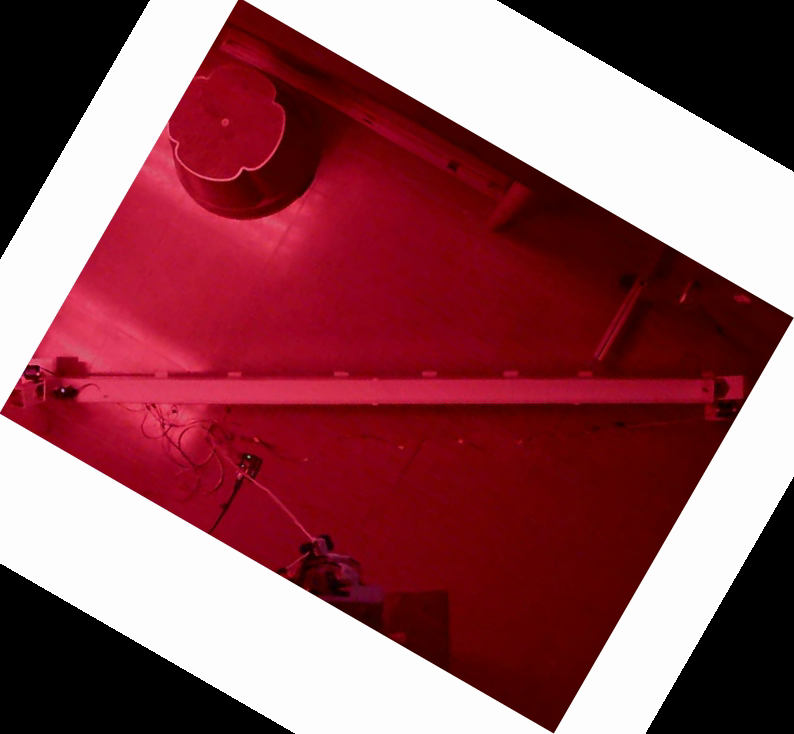

Rotation previews:  65%|██████████████▏       | 11/17 [00:05<00:03,  2.00file/s]

### Rotation preview: m311_07042025_19_43_52_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.41s`  
Rotated canvas: `794 x 735`

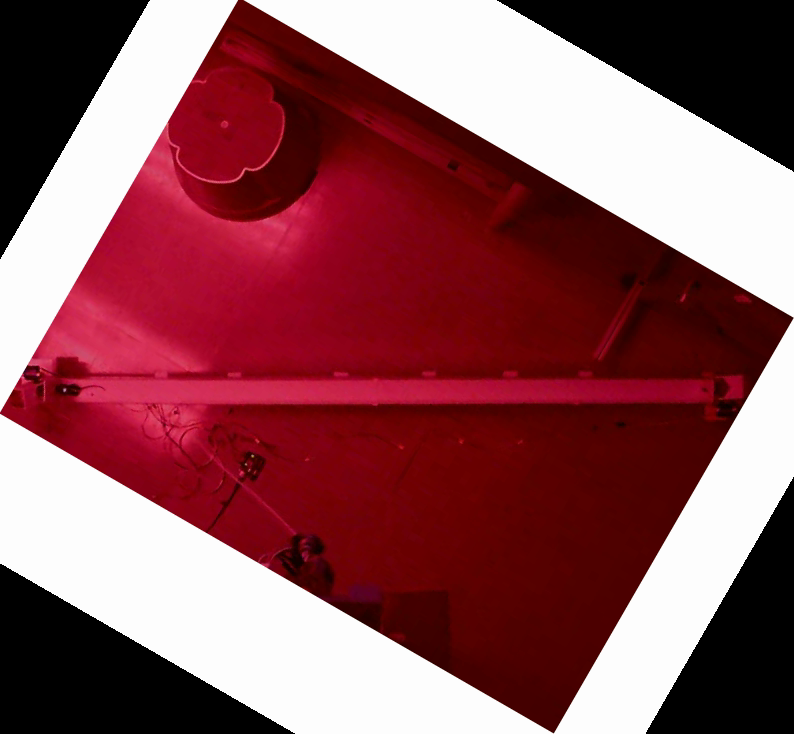

Rotation previews:  71%|███████████████▌      | 12/17 [00:06<00:02,  2.01file/s]

### Rotation preview: m311_07042025_20_10_39_concactenatedbehavCam00_behavCam16.mp4
Angle: `30.0`  
Preview time: `136.08s`  
Rotated canvas: `794 x 735`

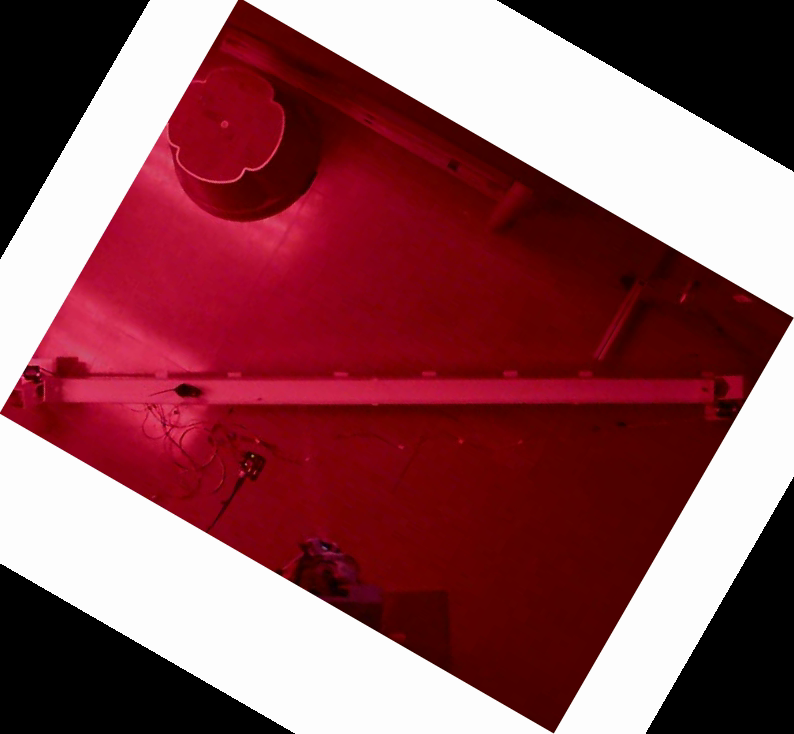

Rotation previews:  76%|████████████████▊     | 13/17 [00:06<00:01,  2.02file/s]

### Rotation preview: m311_08042025_16_21_42_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.33s`  
Rotated canvas: `794 x 735`

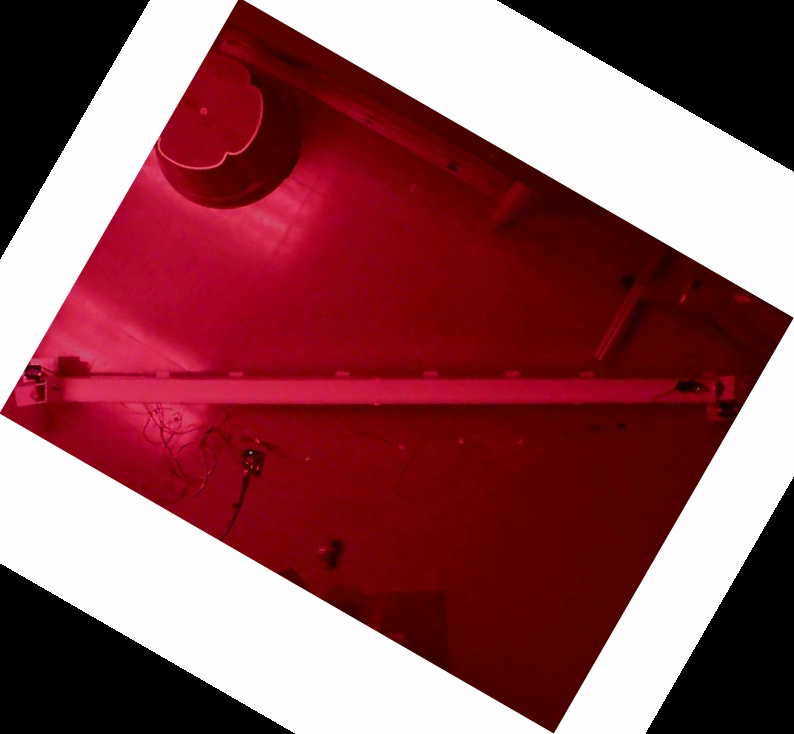

Rotation previews:  82%|██████████████████    | 14/17 [00:07<00:01,  2.03file/s]

### Rotation preview: m311_09042025_15_28_20_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.42s`  
Rotated canvas: `794 x 735`

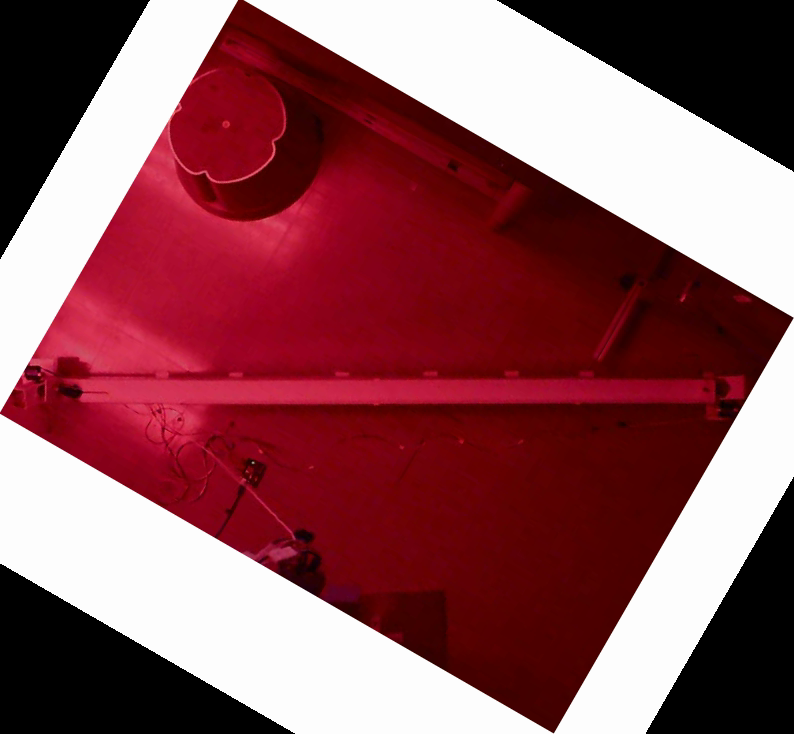

Rotation previews:  88%|███████████████████▍  | 15/17 [00:07<00:00,  2.04file/s]

### Rotation preview: m311_10042025_16_39_41_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.41s`  
Rotated canvas: `794 x 735`

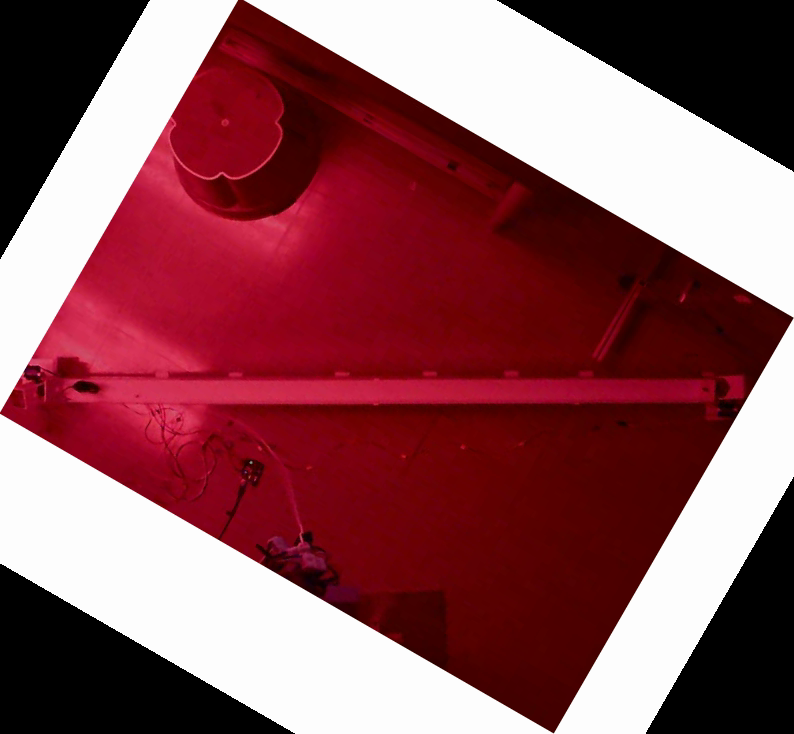

Rotation previews:  94%|████████████████████▋ | 16/17 [00:08<00:00,  2.01file/s]

### Rotation preview: m311_11042025_20_13_24_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.41s`  
Rotated canvas: `794 x 735`

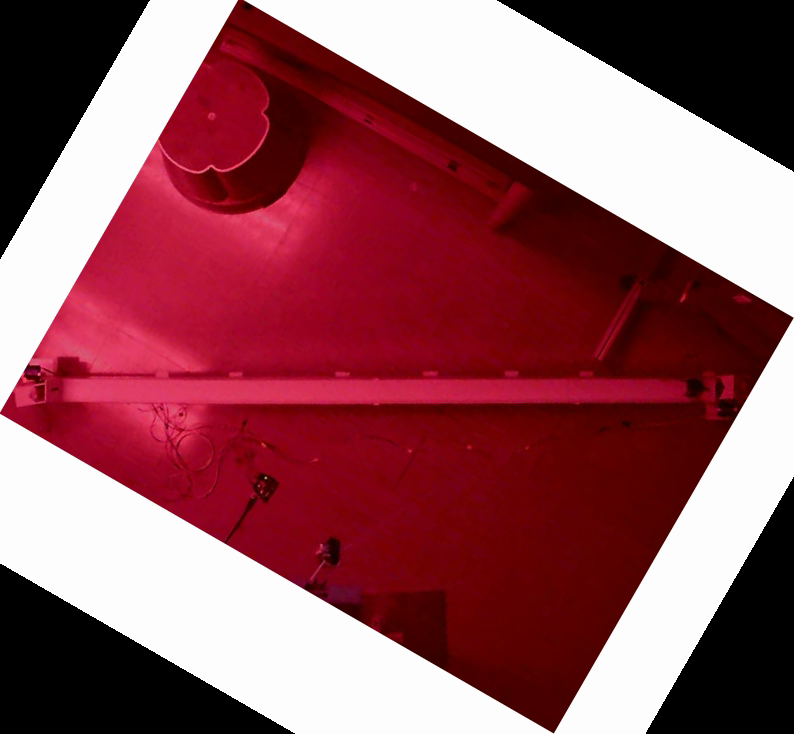

Rotation previews: 100%|██████████████████████| 17/17 [00:08<00:00,  1.92file/s]


,file_name,preview_time_sec,angle_degrees,rotated_width,rotated_height
0,m311_02042025_19_15_29_concactenatedbehavCam00...,171.466667,30.0,794,735
1,m311_03042025_15_39_01_concactenatedbehavCam00...,171.425000,30.0,794,735
2,m311_04022025_19_15_29_concactenatedbehavCam00...,171.466667,30.0,794,735
3,m311_04032025_15_39_01_concactenatedbehavCam00...,171.425000,30.0,794,735
4,m311_04042025_21_05_03_concactenatedbehavCam00...,171.416666,30.0,794,735
5,m311_04082025_16_21_42_concactenatedbehavCam00...,171.333334,30.0,794,735
6,m311_04092025_15_28_20_concactenatedbehavCam00...,171.416666,30.0,794,735
7,m311_04102025_16_39_41_concactenatedbehavCam00...,171.408333,30.0,794,735
8,m311_05042025_18_35_11_concactenatedbehavCam00...,113.525000,30.0,794,735
9,m311_05042025_19_12_36_concactenatedbehavCam00...,171.408333,30.0,794,735


In [7]:
rotation_preview_results = preview_rotation_only(
    config_df=video_config_df,
    preview_time_fraction=preview_time_fraction,
)

rotation_preview_results

Crop previews:   0%|                                   | 0/17 [00:00<?, ?file/s]

### Rotation + crop preview: m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.47s`  
Crop box: `x=49, y=372, w=661, h=35`

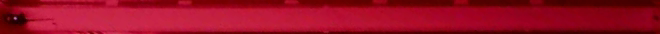

Crop previews:   6%|█▌                         | 1/17 [00:00<00:13,  1.18file/s]

### Rotation + crop preview: m311_03042025_15_39_01_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.43s`  
Crop box: `x=49, y=372, w=661, h=35`

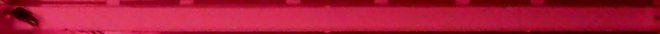

Crop previews:  12%|███▏                       | 2/17 [00:01<00:09,  1.60file/s]

### Rotation + crop preview: m311_04022025_19_15_29_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.47s`  
Crop box: `x=49, y=372, w=661, h=35`

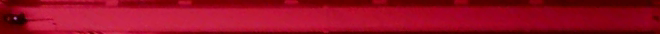

Crop previews:  18%|████▊                      | 3/17 [00:01<00:07,  1.79file/s]

### Rotation + crop preview: m311_04032025_15_39_01_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.43s`  
Crop box: `x=49, y=372, w=661, h=35`

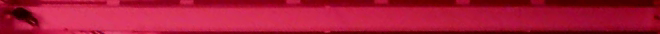

Crop previews:  24%|██████▎                    | 4/17 [00:02<00:06,  1.91file/s]

### Rotation + crop preview: m311_04042025_21_05_03_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.42s`  
Crop box: `x=49, y=372, w=661, h=35`

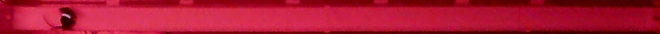

Crop previews:  29%|███████▉                   | 5/17 [00:02<00:06,  1.98file/s]

### Rotation + crop preview: m311_04082025_16_21_42_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.33s`  
Crop box: `x=49, y=372, w=661, h=35`

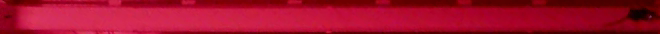

Crop previews:  35%|█████████▌                 | 6/17 [00:03<00:05,  2.03file/s]

### Rotation + crop preview: m311_04092025_15_28_20_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.42s`  
Crop box: `x=49, y=372, w=661, h=35`

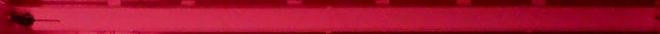

Crop previews:  41%|███████████                | 7/17 [00:03<00:04,  2.06file/s]

### Rotation + crop preview: m311_04102025_16_39_41_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.41s`  
Crop box: `x=49, y=372, w=661, h=35`

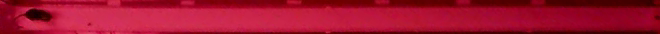

Crop previews:  47%|████████████▋              | 8/17 [00:04<00:04,  2.08file/s]

### Rotation + crop preview: m311_05042025_18_35_11_concactenatedbehavCam00_behavCam13.mp4
Angle: `30.0`  
Preview time: `113.53s`  
Crop box: `x=49, y=372, w=661, h=35`

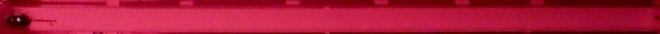

Crop previews:  53%|██████████████▎            | 9/17 [00:04<00:03,  2.09file/s]

### Rotation + crop preview: m311_05042025_19_12_36_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.41s`  
Crop box: `x=49, y=372, w=661, h=35`

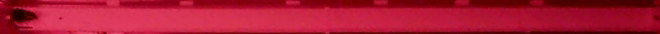

Crop previews:  59%|███████████████▎          | 10/17 [00:05<00:03,  2.09file/s]

### Rotation + crop preview: m311_06042025_18_46_48_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.41s`  
Crop box: `x=49, y=372, w=661, h=35`

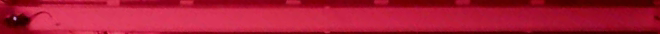

Crop previews:  65%|████████████████▊         | 11/17 [00:05<00:02,  2.10file/s]

### Rotation + crop preview: m311_07042025_19_43_52_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.41s`  
Crop box: `x=49, y=372, w=661, h=35`

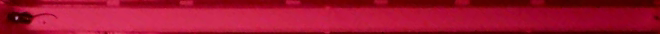

Crop previews:  71%|██████████████████▎       | 12/17 [00:06<00:02,  2.10file/s]

### Rotation + crop preview: m311_07042025_20_10_39_concactenatedbehavCam00_behavCam16.mp4
Angle: `30.0`  
Preview time: `136.08s`  
Crop box: `x=49, y=372, w=661, h=35`

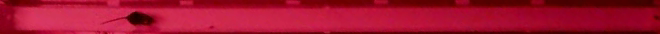

Crop previews:  76%|███████████████████▉      | 13/17 [00:06<00:02,  1.82file/s]

### Rotation + crop preview: m311_08042025_16_21_42_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.33s`  
Crop box: `x=49, y=372, w=661, h=35`

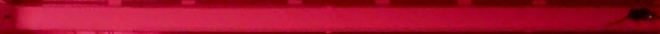

Crop previews:  82%|█████████████████████▍    | 14/17 [00:07<00:01,  1.59file/s]

### Rotation + crop preview: m311_09042025_15_28_20_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.42s`  
Crop box: `x=49, y=372, w=661, h=35`

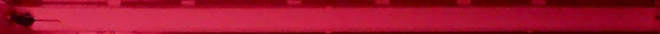

Crop previews:  88%|██████████████████████▉   | 15/17 [00:08<00:01,  1.72file/s]

### Rotation + crop preview: m311_10042025_16_39_41_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.41s`  
Crop box: `x=49, y=372, w=661, h=35`

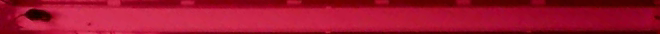

Crop previews:  94%|████████████████████████▍ | 16/17 [00:08<00:00,  1.83file/s]

### Rotation + crop preview: m311_11042025_20_13_24_concactenatedbehavCam00_behavCam20.mp4
Angle: `30.0`  
Preview time: `171.41s`  
Crop box: `x=49, y=372, w=661, h=35`

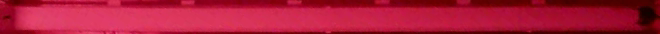

Crop previews: 100%|██████████████████████████| 17/17 [00:08<00:00,  1.89file/s]


,file_name,preview_time_sec,angle_degrees,crop_x,crop_y,crop_width,crop_height
0,m311_02042025_19_15_29_concactenatedbehavCam00...,171.466667,30.0,49,372,661,35
1,m311_03042025_15_39_01_concactenatedbehavCam00...,171.425000,30.0,49,372,661,35
2,m311_04022025_19_15_29_concactenatedbehavCam00...,171.466667,30.0,49,372,661,35
3,m311_04032025_15_39_01_concactenatedbehavCam00...,171.425000,30.0,49,372,661,35
4,m311_04042025_21_05_03_concactenatedbehavCam00...,171.416666,30.0,49,372,661,35
5,m311_04082025_16_21_42_concactenatedbehavCam00...,171.333334,30.0,49,372,661,35
6,m311_04092025_15_28_20_concactenatedbehavCam00...,171.416666,30.0,49,372,661,35
7,m311_04102025_16_39_41_concactenatedbehavCam00...,171.408333,30.0,49,372,661,35
8,m311_05042025_18_35_11_concactenatedbehavCam00...,113.525000,30.0,49,372,661,35
9,m311_05042025_19_12_36_concactenatedbehavCam00...,171.408333,30.0,49,372,661,35


In [13]:
cropped_preview_results = preview_rotated_and_cropped(
    config_df=video_config_df,
    preview_time_fraction=preview_time_fraction,
)

cropped_preview_results

In [10]:
rotation_batch_results = batch_rotate_from_config(
    config_df=video_config_df,
    rotated_output_dir=rotated_output_dir,
    overwrite=overwrite_existing,
)

rotation_batch_results

Rotate files: 100%|██████████████████████████| 17/17 [00:00<00:00, 575.16file/s]


,input_file,output_file,status
0,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,skipped_existing
1,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,skipped_existing
2,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,skipped_existing
3,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,skipped_existing
4,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,skipped_existing
5,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,skipped_existing
6,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,skipped_existing
7,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,skipped_existing
8,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,skipped_existing
9,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,skipped_existing


In [14]:
crop_batch_results = batch_crop_from_config(
    config_df=video_config_df,
    rotated_output_dir=rotated_output_dir,
    cropped_output_dir=cropped_output_dir,
    overwrite=overwrite_existing,
)

crop_batch_results

Crop files:   0%|                                      | 0/17 [00:00<?, ?file/s]

m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20_rotated.avi:   0%| | 0

m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20_rotated.avi:   2%| | 7

m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20_rotated.avi:   4%| | 1

m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20_rotated.avi:   6%| | 1

m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20_rotated.avi:   9%| | 2

m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20_rotated.avi:  11%| | 3

m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20_rotated.avi:  13%|▏| 4

m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20_rotated.avi:  15%|▏| 5

m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20_rotated.avi:  18%|▏| 6

m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20_rotated.avi:  20%|▏| 6

m311_02042025_19_15_29_concactenatedbehavCam00_behavCam20_rotated.avi:  22%|▏| 7

m311_02042025_19

,input_file,output_file,duration_sec,input_codec,crop_x,crop_y,crop_width,crop_height,source_input_file,rotated_input_file,status
0,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,342.933333,mjpeg,49,372,661,35,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,processed
1,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,342.850000,mjpeg,49,372,661,35,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,processed
2,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,342.933333,mjpeg,49,372,661,35,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,processed
3,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,342.850000,mjpeg,49,372,661,35,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,processed
4,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,342.833333,mjpeg,49,372,661,35,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,processed
5,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,342.666667,mjpeg,49,372,661,35,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,processed
6,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,342.833333,mjpeg,49,372,661,35,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,processed
7,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,342.816667,mjpeg,49,372,661,35,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,processed
8,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,227.050000,mjpeg,49,372,661,35,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,processed
9,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,342.816667,mjpeg,49,372,661,35,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,processed
